# Retail Performance Analysis

## 1. Business Case

Favorita es una cadena de supermercados en Ecuador que busca comprender los factores que influyen en el desempeño de sus tiendas para mejorar la toma de decisiones comerciales.

En este proyecto se integrarán múltiples fuentes de datos para analizar patrones de ventas, promociones, transacciones y otros factores externos que puedan afectar el rendimiento del negocio.

---

### Objetivo

Analizar el desempeño comercial de Favorita mediante técnicas de análisis de datos para identificar patrones, oportunidades de mejora y generar recomendaciones basadas en evidencia.

## 2. Exploración inicial del dataset

In [379]:
import pandas as pd

In [380]:
train = pd.read_csv("train.csv")

In [381]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [382]:
print(f"Filas: {train.shape[0]:,}")
print(f"Columnas: {train.shape[1]}")

Filas: 3,000,888
Columnas: 6


In [383]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [384]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


## 3. Evaluación de la calidad de los datos

Antes de comenzar el análisis exploratorio, se evalúa la calidad del conjunto de datos para identificar posibles problemas que puedan afectar los resultados, como valores faltantes, registros duplicados o inconsistencias.

In [385]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [386]:
train.duplicated().sum()

np.int64(0)

### Hallazgos

El dataset principal *no* presenta *valores nulos* en ninguna de sus seis variables. Asimismo, no se identificaron registros duplicados, lo que indica una *buena calidad* inicial *de los datos* y permite continuar con el análisis sin necesidad de realizar tratamientos relacionados con datos faltantes o duplicados.

## 4. Comprensión del dataset

Una vez verificada la calidad inicial de los datos, se realiza una exploración de las principales variables para comprender el alcance del conjunto de datos y obtener un contexto del negocio antes de iniciar el análisis exploratorio.

In [387]:
num_stores = train["store_nbr"].nunique()

print(f"Número de tiendas: {num_stores}")

Número de tiendas: 54


In [388]:
num_product_families = train["family"].nunique()

print(f"Número de familias de productos: {num_product_families}")

Número de familias de productos: 33


In [389]:
train["family"].value_counts().head(10)

family
AUTOMOTIVE      90936
BABY CARE       90936
BEAUTY          90936
BEVERAGES       90936
BOOKS           90936
BREAD/BAKERY    90936
CELEBRATION     90936
CLEANING        90936
DAIRY           90936
DELI            90936
Name: count, dtype: int64

In [390]:
start_date = train["date"].min()
end_date = train["date"].max()

print(f"Fecha inicial: {start_date}")
print(f"Fecha final: {end_date}")

Fecha inicial: 2013-01-01
Fecha final: 2017-08-15


### Hallazgos

El conjunto de datos abarca 54 sucursales y 33 familias de productos distribuidas a lo largo de casi cinco años de operación, lo que proporciona una base suficientemente amplia para identificar patrones comerciales y tendencias temporales.

## 5. Preparación de los datos
Con el fin de facilitar el análisis temporal, la columna date se convierte al formato datetime, permitiendo utilizar funciones especializadas para el manejo de fechas y series de tiempo.

In [391]:
train["date"] = pd.to_datetime(train["date"])

In [392]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


### Hallazgos

La conversión fue exitosa. La variable date pasó de tipo object a datetime64, lo que permitirá realizar agrupaciones temporales, extraer componentes como año o mes y construir visualizaciones cronológicas.

In [393]:
daily_sales = train.groupby("date", as_index=False)["sales"].sum()

In [394]:
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


### Hallazgos

Se consolidaron las ventas de todas las tiendas y familias de productos en un único registro por fecha. Este nuevo DataFrame servirá como base para el análisis de tendencias temporales.

## 6. Análisis Exploratorio de Datos (EDA)

Analizar la evolución de las ventas totales de Favorita a lo largo del tiempo para identificar tendencias generales, patrones estacionales o cambios relevantes en el desempeño comercial.

### 6.1 Evolución de las ventas en el tiempo

In [395]:
import matplotlib.pyplot as plt

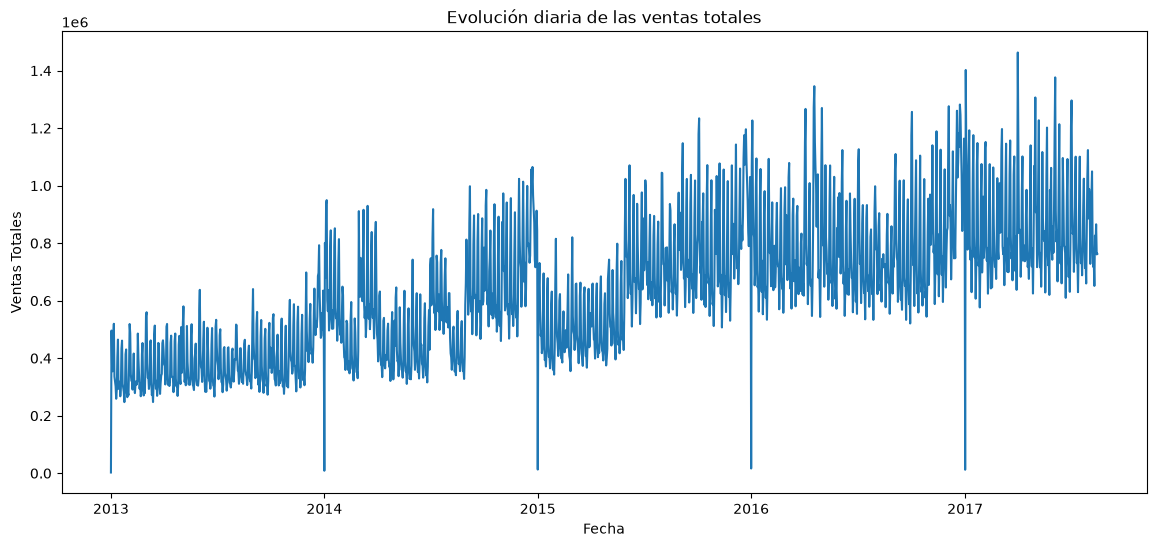

In [396]:
plt.figure(figsize=(14,6))

plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Evolución diaria de las ventas totales")
plt.xlabel("Fecha")
plt.ylabel("Ventas Totales")

plt.show()

### Hallazgos

Se observa una tendencia creciente en las ventas totales a lo largo del período analizado, lo que sugiere un incremento sostenido en la actividad comercial de Favorita. Asimismo, se identifican picos y caídas pronunciadas en determinadas fechas, cuyo origen será analizado en etapas posteriores del proyecto mediante información de promociones y días festivos.

### 6.2 Tendencia de las ventas (Promedio móvil)

In [397]:
daily_sales["rolling_30"] = daily_sales["sales"].rolling(window=30).mean()

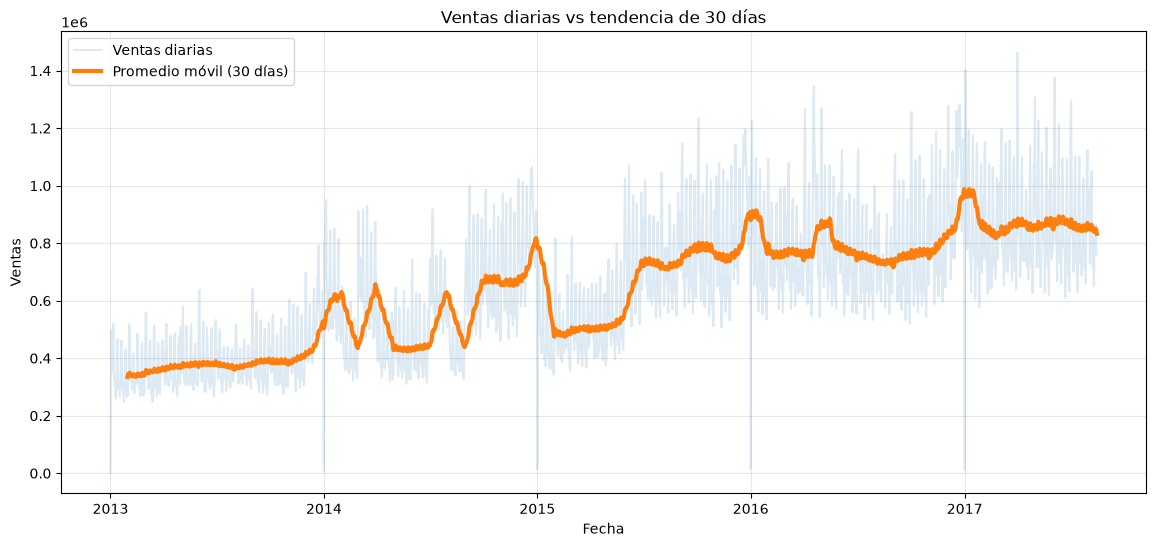

In [398]:
plt.figure(figsize=(14,6))

plt.plot(daily_sales["date"],
         daily_sales["sales"],
         alpha=0.15,
         label="Ventas diarias")

plt.plot(daily_sales["date"],
         daily_sales["rolling_30"],
         linewidth=3,
         label="Promedio móvil (30 días)")

plt.title("Ventas diarias vs tendencia de 30 días")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6.3 Ventas por familia de productos

In [399]:
sales_by_family = (
    train.groupby("family")["sales"]
         .sum()
         .sort_values(ascending=False)
)

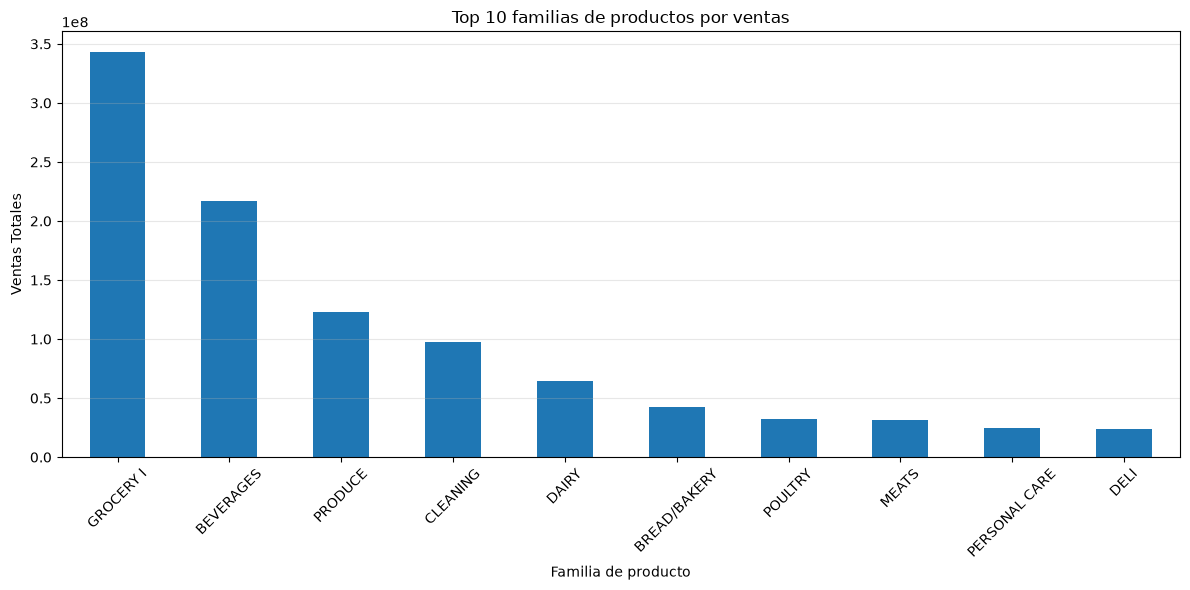

In [400]:
plt.figure(figsize=(12,6))

sales_by_family.head(10).plot(kind="bar", figsize=(12,6))

plt.title("Top 10 familias de productos por ventas")
plt.xlabel("Familia de producto")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Hallazgos

Las familias GROCERY I y BEVERAGES concentran el mayor volumen de ventas del negocio, seguidas por PRODUCE y CLEANING. El resto del Top 10 presenta una distribución más equilibrada. Estos resultados indican que una parte importante de las ventas de Favorita proviene de productos de consumo cotidiano y alta rotación.

### 6.4 Integración del dataset de tiendas

Incorporar la información geográfica y estructural de las tiendas para enriquecer el análisis de ventas y permitir comparaciones por ciudad, estado, tipo de tienda y clúster.

In [401]:
stores = pd.read_csv("stores.csv")

In [402]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [403]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   store_nbr  54 non-null     int64
 1   city       54 non-null     str  
 2   state      54 non-null     str  
 3   type       54 non-null     str  
 4   cluster    54 non-null     int64
dtypes: int64(2), str(3)
memory usage: 2.2 KB


In [404]:
sales_stores = train.merge(stores, on="store_nbr")

In [405]:
sales_stores.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [406]:
city_sales = sales_stores.groupby("city")["sales"].sum().sort_values(ascending=False)

In [407]:
city_sales.head(10)

city
Quito            5.567418e+08
Guayaquil        1.229673e+08
Cuenca           4.916860e+07
Ambato           4.030440e+07
Santo Domingo    3.583432e+07
Machala          3.338680e+07
Cayambe          2.832556e+07
Latacunga        2.118226e+07
Daule            1.918802e+07
Loja             1.886000e+07
Name: sales, dtype: float64

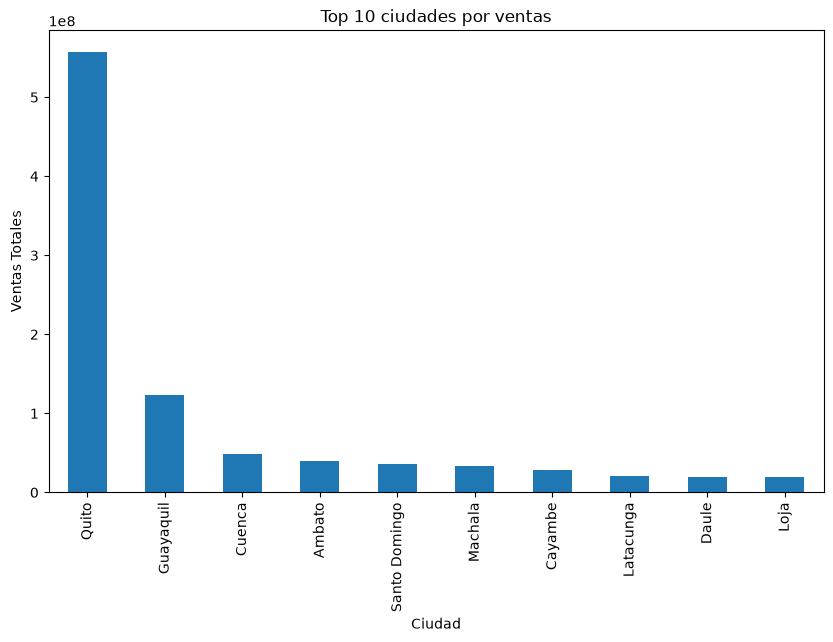

In [408]:
plt.figure(figsize=(10,6))

city_sales.head(10).plot(kind="bar")

plt.title("Top 10 ciudades por ventas")
plt.xlabel("Ciudad")
plt.ylabel("Ventas Totales")

plt.show()

### Hallazgos

Quito concentra la mayor parte de las ventas de la cadena, superando ampliamente al resto de las ciudades. Sin embargo, este resultado representa ventas acumuladas y puede estar influenciado por el número de sucursales presentes en cada ciudad, por lo que no debe interpretarse directamente como un indicador de rendimiento promedio por tienda.

### 6.5 Análisis por tienda

In [436]:
store_sales = train.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)

store_sales.head(10)

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64

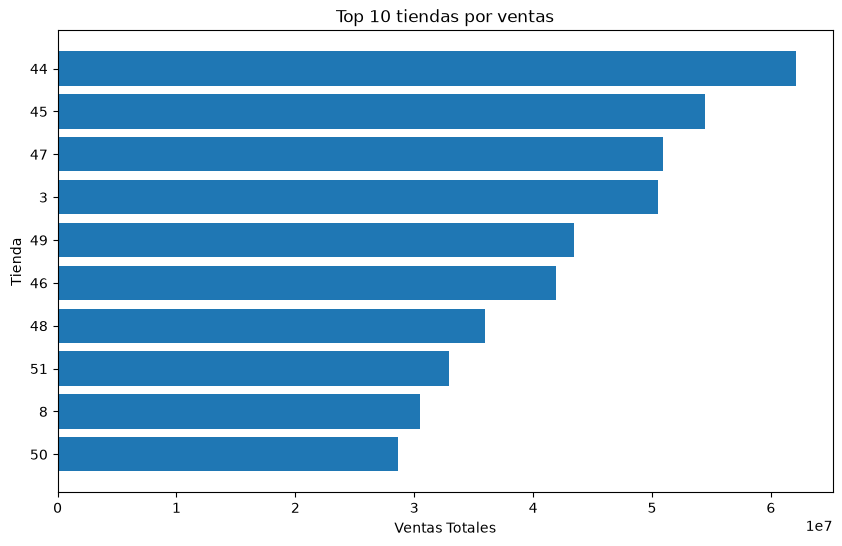

In [437]:
top_stores = store_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top_stores.index.astype(str), top_stores.values)

plt.title("Top 10 tiendas por ventas")
plt.xlabel("Ventas Totales")
plt.ylabel("Tienda")

plt.show()

### Hallazgo

Las ventas acumuladas presentan diferencias importantes entre las tiendas. La tienda 44 registra el mayor volumen de ventas, seguida por las tiendas 45 y 47. Esto indica que el desempeño comercial varía considerablemente entre sucursales y que algunas tiendas tienen una mayor contribución al resultado total.

### 6.6 Relación entre promociones y ventas

### Relación entre promociones y ventas

Se analiza si existe una relación entre la cantidad de productos en promoción y el volumen promedio de ventas.

In [411]:
promotion_avg = train.groupby("onpromotion")["sales"].mean()

promotion_avg.head(10)

onpromotion
0     158.246681
1     467.556532
2     662.925632
3     871.408092
4     969.916135
5    1010.659835
6    1022.854287
7    1022.567058
8    1174.757003
9    1258.733993
Name: sales, dtype: float64

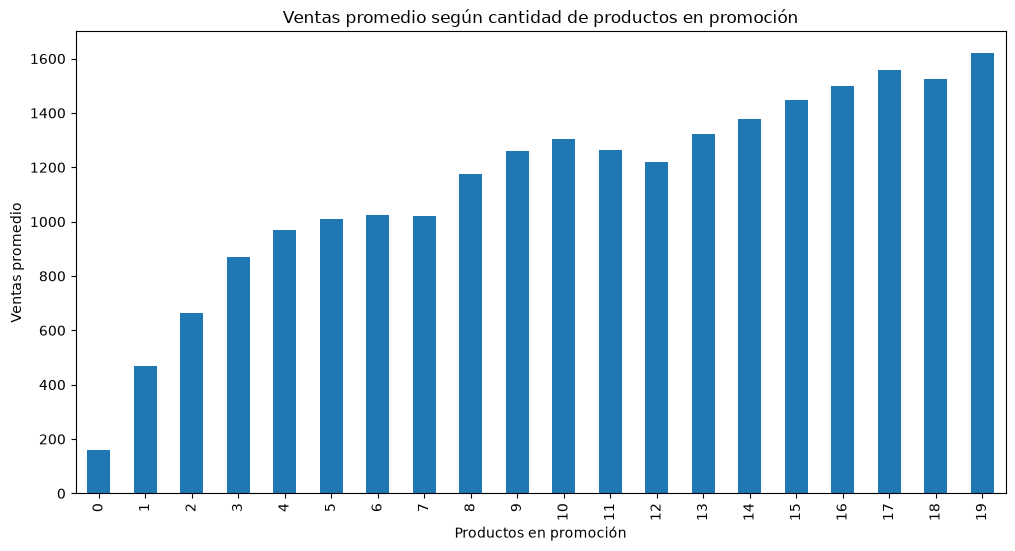

In [412]:
promotion_avg.head(20).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Ventas promedio según cantidad de productos en promoción")
plt.xlabel("Productos en promoción")
plt.ylabel("Ventas promedio")

plt.show()

### Hallazgo

Se observa una relación positiva entre la cantidad de productos en promoción y las ventas promedio. En general, los registros con una mayor cantidad de productos promocionados presentan mayores ventas promedio, aunque existen algunas variaciones y descensos puntuales. Este comportamiento sugiere una posible relación entre las promociones y el desempeño de las ventas, que podría analizarse con mayor profundidad considerando otros factores.

### 6.7 Ventas por tipo de tienda

In [413]:
stores["type"].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

In [414]:
sales_by_type = train.merge(
    stores[["store_nbr", "type"]],
    on="store_nbr"
)

type_sales = sales_by_type.groupby("type")["sales"].sum().sort_values(ascending=False)

type_sales

type
A    3.530438e+08
D    3.510833e+08
C    1.644347e+08
B    1.452606e+08
E    5.982244e+07
Name: sales, dtype: float64

### 6.8 Variabilidad de las ventas

### Hallazgo

El tipo de tienda A registra el mayor volumen total de ventas, seguido muy de cerca por el tipo D. A pesar de contar con la mitad de tiendas que D, ambos tipos presentan ventas totales similares, lo que sugiere diferencias importantes en el desempeño promedio por tienda.

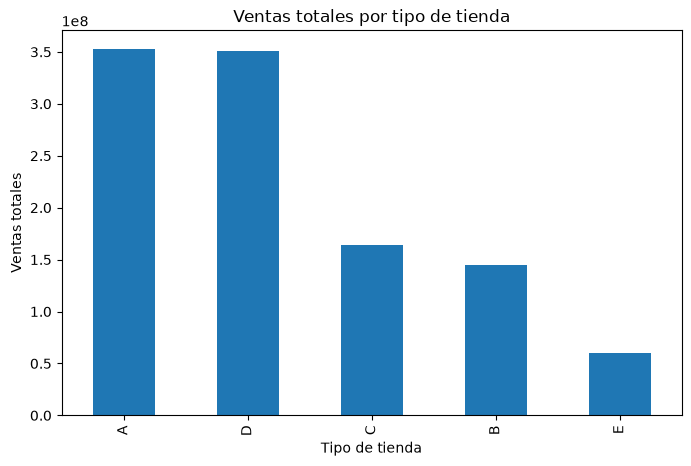

In [415]:
type_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Ventas totales por tipo de tienda")
plt.xlabel("Tipo de tienda")
plt.ylabel("Ventas totales")

plt.show()

In [416]:
avg_sales_type = type_sales / stores["type"].value_counts()

avg_sales_type.sort_values(ascending=False)

type
A    3.922709e+07
D    1.950463e+07
B    1.815758e+07
E    1.495561e+07
C    1.096232e+07
dtype: float64

### Hallazgo

El tipo de tienda A presenta las mayores ventas promedio por establecimiento, con aproximadamente 39.2 millones, seguido por D con 19.5 millones. Esto muestra que las ventas totales dependen no solo del desempeño de cada tienda, sino también del número de establecimientos de cada tipo.

## 7. Análisis de feriados y eventos

Se analiza la información de feriados y eventos para identificar si determinadas fechas pueden estar relacionadas con cambios en el comportamiento de las ventas.

In [417]:
holidays = pd.read_csv("holidays_events.csv")

holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [418]:
holidays.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   type         350 non-null    str  
 2   locale       350 non-null    str  
 3   locale_name  350 non-null    str  
 4   description  350 non-null    str  
 5   transferred  350 non-null    bool 
dtypes: bool(1), str(5)
memory usage: 14.1 KB


In [419]:
holidays["type"].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [420]:
holidays["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

### Hallazgo

La mayoría de los registros corresponden a feriados (Holiday), mientras que los eventos y días adicionales representan una proporción menor. En cuanto a su alcance geográfico, predominan los eventos nacionales, aunque también existe una cantidad importante de eventos locales, lo que permitirá analizar posibles diferencias en el comportamiento de las ventas según la ubicación.

In [421]:
holidays["date"] = pd.to_datetime(holidays["date"])

In [422]:
holidays.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[us]
 1   type         350 non-null    str           
 2   locale       350 non-null    str           
 3   locale_name  350 non-null    str           
 4   description  350 non-null    str           
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[us](1), str(4)
memory usage: 14.1 KB


In [423]:
holidays_period = holidays[
    (holidays["date"] >= train["date"].min()) &
    (holidays["date"] <= train["date"].max())
]

holidays_period.shape

(286, 6)

In [424]:
holidays_period.head()

,date,type,locale,locale_name,description,transferred
41,2013-01-01,Holiday,National,Ecuador,Primer dia del ano,False
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano,False
44,2013-02-11,Holiday,National,Ecuador,Carnaval,False
45,2013-02-12,Holiday,National,Ecuador,Carnaval,False


In [425]:
holidays_period["type"].value_counts()

type
Holiday       175
Event          56
Additional     38
Transfer        9
Work Day        5
Bridge          3
Name: count, dtype: int64

In [426]:
holidays_period["description"].value_counts().head(10)

description
Carnaval                         10
Fundacion de Cuenca               6
Primer dia del ano                5
Fundacion de Manta                5
Provincializacion de Cotopaxi     5
Cantonizacion de Libertad         5
Cantonizacion de Riobamba         5
Viernes Santo                     5
Dia del Trabajo                   5
Dia de la Madre-1                 5
Name: count, dtype: int64

In [427]:
event_dates = holidays_period["date"].drop_duplicates()

In [428]:
daily_sales["is_event"] = daily_sales["date"].isin(event_dates)

In [429]:
daily_sales.groupby("is_event")["sales"].mean()

is_event
False    627547.659762
True     694431.362793
Name: sales, dtype: float64

### Hallazgo

Los días asociados con algún evento presentan ventas promedio superiores a los días sin eventos. En promedio, las ventas fueron de aproximadamente 694,431 en días con eventos frente a 627,548 en días normales, una diferencia cercana al 10.7%. Este comportamiento sugiere una posible relación entre las fechas especiales y el desempeño comercial, aunque no permite establecer causalidad por sí solo.

In [430]:
event_sales = daily_sales.merge(
    holidays_period[["date", "type"]].drop_duplicates(),
    on="date",
    how="inner"
)

In [431]:
event_sales.groupby("type")["sales"].mean().sort_values(ascending=False)

type
Additional    868954.744636
Transfer      833536.042171
Bridge        796110.021751
Event         757393.537965
Work Day      663184.707506
Holiday       635062.000846
Name: sales, dtype: float64

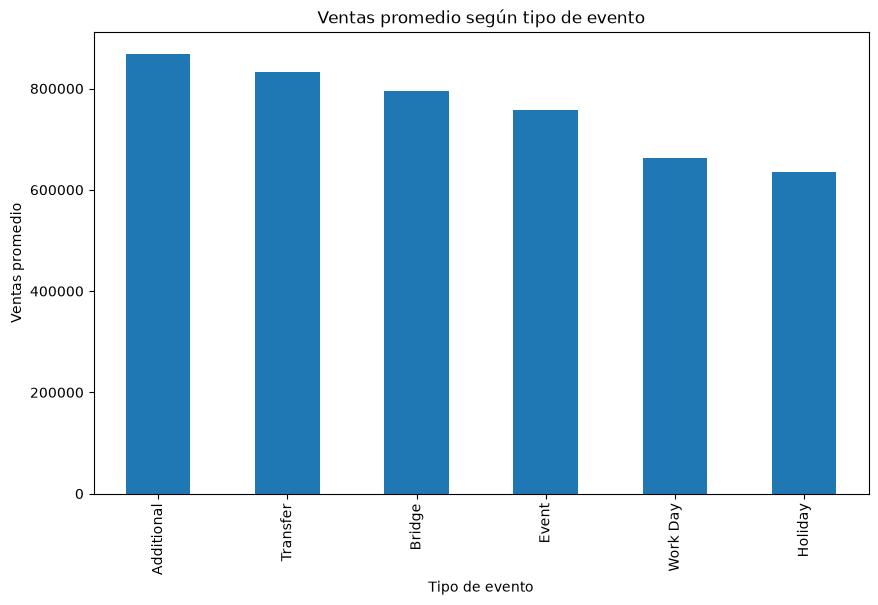

In [433]:
event_sales_avg = event_sales.groupby("type")["sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

event_sales_avg.plot(kind="bar")

plt.title("Ventas promedio según tipo de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Ventas promedio")

plt.show()

### Hallazgo

Las ventas promedio varían según el tipo de evento. Los registros asociados con Additional y Transfer presentan los mayores niveles de ventas promedio, mientras que Holiday y Work Day muestran los valores más bajos dentro de las categorías analizadas. Esto sugiere que el comportamiento de las ventas puede variar dependiendo del tipo de fecha especial, aunque este análisis no permite establecer una relación causal.

## Variabilidad de las ventas por tienda

Se analiza la variabilidad de las ventas diarias de cada tienda mediante la desviación estándar, con el objetivo de identificar establecimientos con un comportamiento de ventas más estable o fluctuante.

In [434]:
store_variability = train.groupby("store_nbr")["sales"].std().sort_values(ascending=False)

store_variability.head(10)

store_nbr
44    2685.282436
45    2384.321416
47    2222.316800
3     2146.185033
49    1897.861943
46    1889.012915
48    1668.493989
11    1360.257967
51    1352.209195
50    1280.877685
Name: sales, dtype: float64

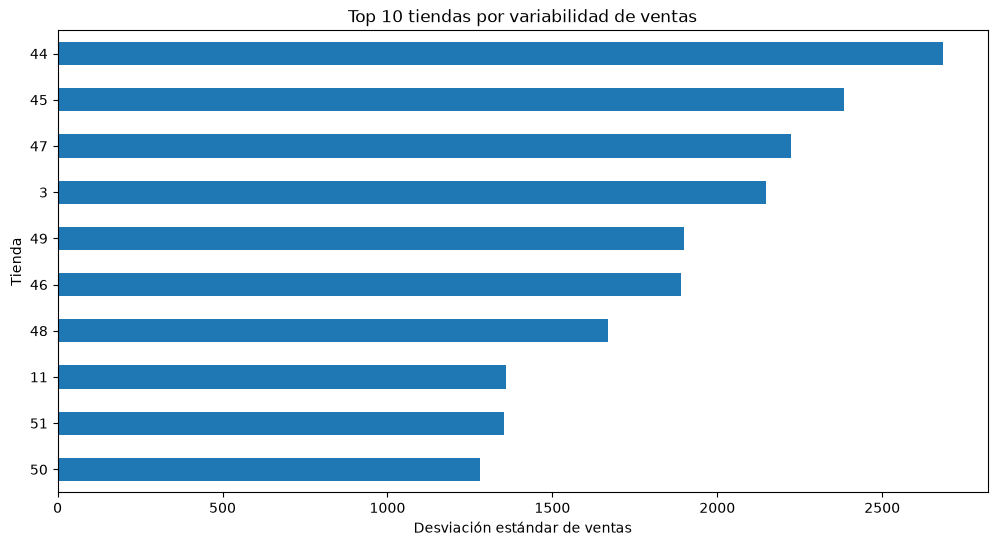

In [435]:
top_variability = store_variability.head(10)

plt.figure(figsize=(12, 6))

top_variability.sort_values().plot(kind="barh")

plt.title("Top 10 tiendas por variabilidad de ventas")
plt.xlabel("Desviación estándar de ventas")
plt.ylabel("Tienda")

plt.show()

### Hallazgo

Las tiendas 44, 45 y 47 presentan la mayor variabilidad en sus ventas diarias, indicando fluctuaciones más pronunciadas durante el período analizado. La tienda 44 destaca tanto por su nivel de ventas totales como por su variabilidad, por lo que podría ser relevante analizar posteriormente los factores asociados a sus cambios de demanda.

## 8. Conclusiones y recomendaciones

A partir del análisis exploratorio realizado, se identificaron diversos patrones relacionados con la evolución temporal de las ventas, el desempeño de las familias de productos, las tiendas, las ciudades, las promociones y los eventos especiales.

## Conclusiones principales

- Las ventas totales presentan una tendencia creciente durante el período analizado, aunque con fluctuaciones importantes entre días.
- La familia de productos `GROCERY I` concentra el mayor volumen de ventas, seguida por `BEVERAGES` y `PRODUCE`.
- Quito concentra las mayores ventas acumuladas entre las ciudades analizadas, seguida por Guayaquil; sin embargo, estas diferencias pueden estar influenciadas por el número de tiendas presentes en cada ciudad.
- Algunas tiendas presentan simultáneamente altos niveles de ventas y una elevada variabilidad, destacando especialmente la tienda 44.
- Se observa una relación positiva entre la cantidad de productos en promoción y las ventas promedio, aunque este comportamiento no permite establecer causalidad.
- El desempeño de las ventas promedio varía según el tipo de evento o fecha especial, mostrando diferencias entre categorías como `Additional`, `Transfer`, `Event` y `Holiday`.

## Recomendaciones de negocio

1. **Analizar las tiendas de mayor variabilidad:** investigar las causas de las fluctuaciones en tiendas como la 44, 45 y 47 para identificar oportunidades de planificación de inventario y demanda.

2. **Priorizar las principales familias de productos:** mantener especial atención sobre categorías como `GROCERY I`, `BEVERAGES` y `PRODUCE`, debido a su importante participación en las ventas.

3. **Optimizar las promociones:** profundizar el análisis de las promociones para determinar qué productos, tiendas y períodos generan mejores resultados, evitando asumir que una mayor cantidad de productos promocionados necesariamente causa mayores ventas.

4. **Considerar la temporalidad:** utilizar patrones estacionales y fechas especiales para mejorar la planificación de inventario, personal y estrategias comerciales.

5. **Analizar diferencias geográficas:** estudiar el comportamiento de las principales ciudades y tiendas para adaptar las estrategias comerciales a las características de cada mercado.